In [1]:
''' 
Using an external trigger, compare time between successive packet timestamps. Inconsistencies suggest drifting chip clocks. 

    - Too few ticks: chip occasionally fails to register the clock pulse 
    - Too many ticks: noise on clock line 
    - Variation between too few and too many ticks, with constant mean: slewing/jitter of the clock or ext_trig pulse
'''

import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm
import io
import tarfile
import os
import math

from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev
from pathlib import Path
from datetime import datetime
from scipy import stats

##########################################################
# Initialize parameters  
##########################################################

# set1-7 datafiles. This file should be run after disabling hot channels, because sometimes hot channels
# impact pedestal values
#filename = "../data/packet-warm_timing_120s_7tiles_2026_1_13.hdf5"
#filename = "../data/packet-warm_timing_120s_7tiles_2026_1_13.hdf5"
#filename = "../data/packet-warm_timing_300ns_120s_7tiles_2026_1_13.hdf5"
#filename = "../data/packet-warm_timing_200ns_120s_7tiles_2026_1_15.hdf5"
#filename = "../data/packet-warm_timing_200ns_120s_7tiles_2026_1_19.hdf5"
#filename = "../data/packet-warm_timing_150cycles_600s_7tiles_2026_1_21.hdf5"
#filename = "../data/packet-warm_timing_150cycles_600s_7tiles_2026_1_21_10_40.hdf5"
#filename = "../data/test-warm_timing_exclude_duplicates.hdf5"
#filename = "../data/packet-warm_test_enable_reset.hdf5"

# cold test of tile 10
filename = "/data/v3/10x16/20260206_tile_4K04087_tests/data/cold/packet-cold_timing_480s_t10_start_w_sync.hdf5"

# use the data filename to determine if this is a cold or warm run
temp = "cold"

if temp not in filename:
    temp = "warm"
    if temp not in filename:
        print(f"The filename did not indicate if this was a cold or warm run")
        temp = "not indicated"
        
# tiles tested in this filename or the subset of tiles on which you wish to check tally 
tiles = [1,2,3,4,5,6,7,8,9,10]

# serial numbers for set 1 of tiles 1-10
#chip_serial_number_list = ['', '4k02056', '4k03591', '4k01892', '4k02219', '4k02371', '4k04834', '4k00101', '4K00277', '4K03329', '4K04087' ]

# serial numbers for set 2 of tiles 1-10
chip_serial_number_list = ['', '4k04582', '4k04905', '4k03080', '4k04087', '4k04249', '4k00104', '4k01300', '4K04411', '4K01733', '4K00770' ]

# provide more detailed information for a particular tile
verbose_tile = 10
verbose_chip = 38

# this is the value of the timestamp at which the chip clock rolls over
highest_timestamp = 2**28

# initialize variables needed at the file level
first_tile = True
percent_low_list, percent_high_list, tile_list = [], [], []

# background: packet dataset attributes: 
# ('io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
# 'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
# 'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp')


In [2]:
def get_io_channels(tile):

    # each tile has up to 4 io_channels that uniquely identify the tile within an io_group
    io_ch_per_tile = [
        [],
        [1,2,3,4],
        [5,6,7,8],
        [9,10,11,12],
        [13,14,15,16],
        [17,18,19,20],
        [21,22,23,24],
        [25,26,27,28],
        [29,30,31,32],
        [33,34,35,36],
        [37,38,39,40]
        ]
    
    return io_ch_per_tile[tile]


In [3]:
# if 2 packets from the same chip/channel have exactly the same timestamp, see what other attributes 
# the 2 packets have
def analyze_duplicate_pkts(tile, chip, pkt1, pkt2, pkt_numb):

    global n_diff_rec_ts, total_n_duplicates, verbose_tile, duplicate_receipt_ts, diff_rec_ts

    pkt_keys = ['io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
                'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
                'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp']

    # check every packet attribute to see if it is duplicated
    for key in pkt_keys:
        pkt1_key = pkt1[key]
        pkt2_key = pkt2[key]

        # do not print out a message if the attribute is receipt timestamp, as this is expected to be different
        if pkt1_key != pkt2_key and key != 'receipt_timestamp':
            print(f"Tile {tile}, Chip {chip} duplicate pkt # {pkt_numb} had unique {key} values [ {pkt1_key}, {pkt2_key} ]")
    
    rec_ts1    = pkt1['receipt_timestamp']
    ts1        = pkt1['timestamp']

    rec_ts2    = pkt2['receipt_timestamp']  
    ts2        = pkt2['timestamp']
     
    
    # count how many times a duplicate timestamp packet has different receipt timestamps

    if rec_ts1    != rec_ts2:
        n_diff_rec_ts  +=1
        diff_rec_ts[chip].append(rec_ts2-rec_ts1)
        #if chip == verbose_chip and tile == verbose_tile:
        #    print(f"\tChip {tile}-{chip} Receipt ts for duplicate pkts [{rec_ts1}, {rec_ts2}]")
                
    else:
        duplicate_receipt_ts[chip] +=1
        print(f"Tile {tile}, Chip {chip} pkt # {pkt_numb} had a duplicate pair with the same receipt timestamps [ {rec_ts1}, {rec_ts2} ] and same timestamps [ {ts1}, {ts2} ]")
    
    total_n_duplicates += 1
    
    return

In [4]:
############################################################################################
# count the missing packets for a given chip using tally
############################################################################################
def check_tally(tile, chip, chip_tally, timestamps):
    
    global verbose_chip, verbose_tile, mode_npkts

    n_duplicates = 0
    missing = 0
    pkt_count = len(chip_tally)
       
    # If chips have no packets then they skipped all of their tallies
    if pkt_count == 0:
        print(f"\tChip {chip} had 0 packets")
        return 0
    
    # tally counts from 0 to 15 then starts again at 0. Count episodes of skipped tallies
    for i in range(len(chip_tally)-1):

        # check for tally skips when tally has rolled over
        if chip_tally[i] > chip_tally[i+1]:
            missing += 15-chip_tally[i] + chip_tally[i+1]

        # check for instances of equal tallies.
        elif chip_tally[i] == chip_tally[i+1]:

            # If the timestamps are the same the chip fired twice (within 1 clock count, or 100ns)
            if timestamps[i+1] == timestamps[i]:
                n_duplicates +=1

            # if the timestamps are different some multiple of 16 tallies must have been skipped. We
            # can figure out how many were skipped by the difference in timestamps
            else:

                # the "int" function rounds down
                missing += int((timestamps[i+1] - timestamps[i]) / 1E7)
                
        else:
            missing += chip_tally[i+1] - chip_tally[i] - 1
    
    if missing > 0:
        print(f'\tChip {chip}: missing tally episodes = {missing:.0f} (each episode could have multiple skipped tallies)')
    
    if chip == verbose_chip and tile == verbose_tile:
        
        fig, ax = plt.subplots(figsize=(10, 3))
        ax.set_title(f'Chip {verbose_chip} Tally\nBenchtop test of v3a tile #{tile} ({chip_serial_number_list[tile]})')
        ax.plot(chip_tally, marker='o')
        ax.set_xlabel("Packet")
        ax.set_ylabel("Tally")
        plt.show 

        fig, ax = plt.subplots(figsize=(10, 3))
        ax.set_title(f'Zoom in on Chip {verbose_chip} Tally (1st 200 pkts only)\nBenchtop test of v3a tile #{tile} ({chip_serial_number_list[tile]})')
        ax.plot(chip_tally[0:200], marker='o')
        ax.set_xlabel("Packet")
        ax.set_ylabel("Tally")
        plt.show         
    
    return missing

In [5]:
def get_timestamps(filename, tile, chip_serial_number):
    
    global pedestals, percent_low_list, percent_high_list, tile_list, verbose_tile, first_tile, total_n_duplicates
    global n_diff_rec_ts, mode_npkts, duplicate_receipt_ts, diff_rec_ts, temp, highest_timestamp
    
    # initialize variables tracked at the tile level
    verbose = False
    good_chip_list, all_chip_list = [],[]
    npkts_list, nchips = [], 0
    n_duplicates_list, n_skipped_ts_list = [], []
    total_n_duplicates = 0
    n_diff_rec_ts, nchips_skipped_tally, noisy_chips = 0, 0, 0
    n_chips_missing_triggers = 0
    pkt1_list, skip_tally_chips = [], []
    duplicate_receipt_ts = [0 for chp in range(256)]
    diff_rec_ts      = [[] for chp in range(256)]
    n_missing        = [0 for chp in range(256)]
    unexplained_list = []
    tile_list.append(tile)
    
    # read packet data from initialized file name
    f = h5py.File(filename, 'r')
    packets = f['packets'][:]  
    npkts = len(packets)

    # print out run statistics for the file
    unixtime = f['packets'][:]['timestamp'][f['packets'][:]['packet_type'] == 4]
    livetime = np.max(unixtime)-np.min(unixtime)   
    print(f"{npkts:,} packets for tile {tile} arriving at an average rate of {npkts/livetime:.0f} pkts/s over {livetime}s of data taking")    

    # get a list of the io_channels that could be enabled for a given tile
    io_channel_ids = get_io_channels(tile)
    
    # mask for the chosen tile
    tile_mask = (packets['io_channel']== io_channel_ids[0]) | (packets['io_channel']== io_channel_ids[1]) | (packets['io_channel']== io_channel_ids[2]) | (packets['io_channel']== io_channel_ids[3])
    packets   = packets[tile_mask]

    data_mask     = packets['packet_type']  == 1
    data_pkts     = packets[data_mask]
    
    # check for tiles with no data    
    if len(data_pkts) ==0: 
        print(f'There are no data packets for tile {tile}')        
        return 
    else:
        print(f"Possibly enabled io_channels for tile {tile}: {io_channel_ids}")

    print(f"\n------------ Results Tile {tile} --------------")
    
    # count invalid packets
    invalid_count = data_pkts['valid_parity'][:].tolist().count(0)
    invalid_percent = 100 * invalid_count / len(data_pkts)
    print(f"{invalid_count} packets (or {invalid_percent}%) had Invalid Parity")
    
    print(f"\nTally Issues (these chips will be excluded from further analysis):")

    reset_add_on = 0
    
    # find the chips that skipped tallies, and count the # of pkts for each chip
    for chip in range(11, 171):

        # mask for channel 0 on each chip
        chip_mask = data_pkts['chip_id'] == chip
        chip_pkts = data_pkts[chip_mask]  
        chip_ts   = chip_pkts['timestamp'][:]

        # count the # of pkts in each chip
        npkts = len(chip_pkts)
        npkts_list.append(npkts)

        nchips+=1 
        
        if npkts == 0:
            print(f"\tChip {chip}: 0 data packets")
            skip_tally_chips.append(chip)
            continue            
        
        # tally records a sequential count (0-15) assigned to each packet as it enters its home shared FIFO
        # when tally is enabled, its value is stored in a combination of local and shared FIFO registers 
        fifo       = chip_pkts['shared_fifo']
        local_fifo = chip_pkts['local_fifo']
        tally = 4 * fifo + local_fifo 
        
        # exclude but log chips who skipped a tally, most likely because of UART FIFO losses
        skipped_tally = check_tally(tile, chip, tally, chip_ts)
        
        if skipped_tally > 0:
            nchips_skipped_tally +=1
            skip_tally_chips.append(chip)

            
    '''
    if the clock (and receipt of an external trigger) were perfect there would be exactly XXX pkts
    for a datafile of XXX seconds with an external trigger of 1Hz, but the pacman clock is not
    precise, some external triggers are not received, and some packets are dropped
        
    Fewer pkts than expected may indicate all external triggers were not received. More pkts 
    than expected may indicate the external trigger line is noisy on that chip, or duplicate
    packets fired for some triggers
        
    '''        
    
    # for each tile record stats for number of pkts
    mode_npkts = mode(npkts_list)

    npkts_low  = sum(1 for x in npkts_list if x < mode_npkts)
    percent_low  = 100*npkts_low /nchips
    percent_low_list.append(percent_low)
    
    npkts_high = sum(1 for x in npkts_list if x > mode_npkts)    
    percent_high = 100*npkts_high /nchips
    percent_high_list.append(percent_high)
    
    npkts_mode = sum(1 for x in npkts_list if x == mode_npkts)   
    percent_mode = 100*npkts_mode/nchips       
    
    # prepare to plot a time series of dt between packets for the 1st 4 chips with the expected # of packets
    graphed_chips = 0
    fig, axis = plt.subplots(1,4, figsize=(20, 3))
    plt.suptitle(f'(Δt between Packets) - 1E7 for 4 chips (all with the expected # of pkts), {temp} test v3a Tile #{tile} ({chip_serial_number})')    

    print(f"\nChips with more or less than the typical # of packets ({mode_npkts}):")
    
    # check the # of clock ticks between successive timestamps on channel 0 of each chip that had the expected # of pkts
    for chip in range(11, 171):

        # disregard chips that skipped tallies or had no packets
        if chip in skip_tally_chips:
            continue
        
        '''
        the external trigger was only sent to channel 0 on each chip because the same clock is
        shared between all channels on a given chip. To find clock irregularities we only need
        to test one channel per chip
        '''

        # mask for the only channel that was enabled for this test (channel 0)
        chip_mask = data_pkts['chip_id'] == chip
        chip_pkts = data_pkts[chip_mask]  
        chip_ts   = chip_pkts['timestamp'][:]    
            
        # initialize variables tracked at the chip level
        dt, pkt_list, n_duplicates, n_skips = [], [], 0, 0
        npkts = len(chip_ts)
        all_chip_list.append(chip)
        
        '''
        Create a list of the time difference between triggers minus 1e7 (the "idealized" difference
        for a perfect chip clock and a perfect 1Hz external trigger)
        '''
        
        if npkts > 2:
                
            for pkt in range(npkts-1):
    
                if chip_ts[pkt+1] > chip_ts[pkt]:

                    test_dt = chip_ts[pkt+1] - chip_ts[pkt] - 1E7
                    
                    dt.append(test_dt)
                    pkt_list.append(pkt)

                    # count instances of missed timestamps. (note: the "int" function rounds down)
                    if test_dt > 8E6:
                        n_skips += int( (chip_ts[pkt+1] - chip_ts[pkt] - 1E7)/1E7 )

                # count and analyze duplicate timestamps but don't add them to the dt list
                elif chip_ts[pkt+1] == chip_ts[pkt]:
                    n_duplicates +=1
                    analyze_duplicate_pkts(tile, chip, chip_pkts[pkt+1], chip_pkts[pkt], pkt)

                # account for the chip timestamps rolling over. This "fix" won't work if a lot of triggers 
                # have been skipped, in which case successive timestamps can have random values relative 
                # to one another
                else:
                    test_dt =  (chip_ts[pkt+1] + highest_timestamp) - chip_ts[pkt] - 1E7
                    dt.append(test_dt)
                    pkt_list.append(pkt)
        
        if tile == verbose_tile and chip == verbose_chip:         

            fig, ax = plt.subplots(1,1, figsize=(6, 3))            
            ax.plot(chip_ts)
            ax.set_title(f"Packet Timestamps for Verbose Chip {chip}\n{temp} test v3a Tile #{tile} ({chip_serial_number})")
            ax.set_xlabel(f'Packet')
            ax.set_ylabel(f'Packet Timestamps')         
            
            fig, ax = plt.subplots(1,1, figsize=(6, 3))
            ax.plot(dt, color = 'g', marker='o', linestyle = 'None')
            ax.set_title(f"Verbose Chip {chip}: Δt between Packets) - 1E7\n{temp} test v3a Tile #{tile} ({chip_serial_number})")
            #ax.set_yscale("log")
            ax.set_ylabel(f'timestamp_i+1 - timestamp_i')
            ax.set_xlabel(f'Packet')
            plt.show

            fig, ax = plt.subplots(1,1, figsize=(10, 3))
            ax.plot(dt, color = 'g', marker='o', linestyle = 'None')
            ax.set_xlim(340, 360)
            ax.set_title(f"Verbose Chip {chip}: Zoom Δt between Packets) - 1E7\n{temp} test v3a Tile #{tile} ({chip_serial_number})")
            ax.set_ylabel(f'timestamp_i+1 - timestamp_i')
            ax.set_xlabel(f'Packet')
            plt.show            
        
        # count how many chips had duplicate packets
        if n_duplicates > 0:
            n_duplicates_list.append(n_duplicates)

        # count how many chips missed an external trigger. This accounting is needed for chips that
        # missed a lot of triggers
        missing = mode_npkts - (npkts - n_duplicates)
        if missing > 0:
            n_chips_missing_triggers +=1        
            print(f"\tChip {chip}: -{missing} missed triggers")
             
        n_skipped_ts_list.append( max(n_skips,missing) )
        
        unexplained = npkts - mode_npkts - n_duplicates
        unexplained_list.append(unexplained)
        
        if unexplained >0:
            noisy_chips +=1
            if n_duplicates > 0:
                print(f"\tChip {chip}: +{n_duplicates} duplicates +{unexplained} extra noise-related packets")        
            else:
                print(f"\tChip {chip}: +{unexplained} extra noise-related packets")

        elif n_duplicates > 0:
            print(f"\tChip {chip}: +{n_duplicates} duplicates")              
        
        if duplicate_receipt_ts[chip] > 0:
            print(f"\nChip {chip} had {duplicate_receipt_ts[chip]} duplicate consequtive receipt timestamps\n")     
        
        # graph non-skip dt's for the 1st 4 good chips (i.e. those with the typical # of packets)
        if npkts == mode_npkts:
    
            # create lists of various timing attributes for a given chip
            good_chip_list.append(int(chip))

            # measure the dispersion of 1st time stamps
            pkt1_list.append(chip_ts[0])
            
            # graph time series of Δt for 4 chips with the expected # of packets
            if graphed_chips < 4:
        
                # exclude dt's where a trigger was dropped to see finer detail on the remaining dt's
                non_skip_dt = [x for x in dt if x < 8E6]
                
                n_dts = len(non_skip_dt)

                non_skip_pkt_list = pkt_list[0: n_dts]
                
                # graph time series of differences between successive timestamps for the 1st 4 chips
                axis[graphed_chips].plot(non_skip_pkt_list, non_skip_dt, color = 'g')
                axis[graphed_chips].set_xlabel(f'Packet Number')
                if graphed_chips==0:
                    axis[graphed_chips].set_ylabel(f'Timestamp_i+1 - Timestamp_i')

                graphed_chips +=1

                if graphed_chips == 3 and verbose:
                    plt.show

                    fig, ax = plt.subplots(1,1, figsize=(6, 3))
                    ax.hist(dt, color = 'g')
                    ax.set_title(f"Δt between Packets) - 1E7: Chip {chip} has expected # pkts ({mode_npkts})\n{temp} test v3a Tile #{tile} ({chip_serial_number})")
                    ax.set_yscale("log")
                    ax.set_xlabel(f'timestamp_i+1 - timestamp_i')
                    ax.set_ylabel(f'# of pkts')
                    plt.show
    
    n_chips_w_duplicates = len(n_duplicates_list) 

    # count the number of chips whose 1st packet is odd. These chips must have missed the last sync
    mode_1st_timestamp = mode(pkt1_list)
    n_missed_sync = sum(1 for x in pkt1_list if x != mode_1st_timestamp)

    if n_missed_sync > 0:
        print(f"\n{n_missed_sync} chips missed the sync (their 1st timestamp was unlike the others)")
    
    # determine the # of triggers that were missed by all chips
    min_skipped_ts = min(n_skipped_ts_list)
    print(f"\nAll chips missed at least {min_skipped_ts} external triggers, indicating a failure to transmit at the")
    print(f"pacman or trigger source")
    
    print(f"\nAmong {total_n_duplicates:,} Duplicate Timestamp Packet Pairs, {n_diff_rec_ts:,} pairs had distinct receipt_timestamps")   

    print(f"\nMost common # of pkts in a chip = {mode_npkts}")
    
    print(f"\n\n ..... SUMMARY OF TIMING RESULTS (Tile {tile}) .....")
    print(f"\n{npkts_mode} chips ({percent_mode:.0f}%) had {mode_npkts} pkts \n\tall chips missed {min_skipped_ts} triggers, likely due to a failure of the pacman to transmit the external trigger")
    print(f"{npkts_low} chips ({percent_low:.0f}%) had too few pkts:\n\t{nchips_skipped_tally} due to UART FIFO losses (tally skips or no packets). These chips were excluded from further timing analysis")
    print(f"\t{n_chips_missing_triggers} due to missed triggers (no tally skips)\n{npkts_high} chips ({percent_high:.0f}%) had too many pkts")
    print(f"\t{n_chips_w_duplicates} had duplicate packets. The duplicates were excluded from the timing analysis. \n\t{noisy_chips} chips had additional non-duplicate packets, likely due to noise on the clock line \n")
    print(f" ................................................ \n\n")
    
    nbins = int(max(npkts_list)/2)
    min_bin = int(min(npkts_list))

    # histogram the number of packets for each chip's channel 0
    fig, ax = plt.subplots(1,1, figsize=(10, 3))
    ax.hist(npkts_list, color = 'g', bins = nbins)
    ax.set_title(f"Number of Packets in each Chip's Channel 0 (mode {mode_npkts:.0f})\n{temp} test v3a Tile #{tile} ({chip_serial_number})")
    ax.set_yscale("log")
    ax.text(10, 2, f"{npkts_mode} chips ({percent_mode:.0f}%) had {mode_npkts} pkts \n    all chips missed {min_skipped_ts} triggers \n\n{npkts_low} chips ({percent_low:.0f}%) had too few pkts:\n    {nchips_skipped_tally} due to UART FIFO losses \n    {n_chips_missing_triggers} due to missed triggers \n\n{npkts_high} chips ({percent_high:.0f}%) had too many pkts \n    {n_chips_w_duplicates} had duplicate packets \n    {noisy_chips} chips had additional non-duplicate packets, likely due to noise on the clock line", color = "r")    
    ax.set_xlabel(f'Number of Packets')
    ax.set_ylabel(f'# of Chips')
    plt.show

    nbins = int(max(n_skipped_ts_list))
    
    fig, ax = plt.subplots(1,1, figsize=(7, 3))
    ax.hist(n_skipped_ts_list, color = 'b', histtype='step', bins = nbins)
    ax.set_title(f"Number of Missed Triggers per Chip\n{temp} test v3a Tile #{tile} ({chip_serial_number})")
    ax.text(10, 10, f"All chips missed {min(n_skipped_ts_list)} triggers (likely a pacman failure to transmit) \n{n_chips_missing_triggers} chips individually failed to register additional triggers", color = "r")
    ax.set_xlabel(f'# of Missed Triggers')
    ax.set_ylabel(f'# Chips')
    ax.set_yscale("log")
    plt.show

    fig, ax = plt.subplots(1,1, figsize=(6, 3))
    ax.bar(all_chip_list, unexplained_list, color = 'b')
    ax.set_title(f"Number of Noise-related Packets per Chip\n{temp} test v3a Tile #{tile} ({chip_serial_number})")
    #ax.text(10, 10, f"All chips missed {min(n_skipped_ts_list)} triggers (likely a pacman failure to transmit) \n{n_chips_missing_triggers} chips individually failed to register additional triggers", color = "r")
    ax.set_xlabel(f'Chip')
    ax.set_ylabel(f'# of Noise Instances')
    ax.set_yscale("log")
    plt.show 
    
    fig, ax = plt.subplots(1,1, figsize=(5, 3))
    ax.hist(pkt1_list, color = 'b', histtype='step', bins = 100)
    ax.set_title(f"1st Timestamp For Each Good Chip\n{temp} test v3a Tile #{tile} ({chip_serial_number})")
    ax.set_xlabel(f'50th Timestamp')
    ax.set_ylabel(f'# Chips')
    ax.set_yscale("log")
    plt.show
    
    return


Data File /data/v3/10x16/20260206_tile_4K04087_tests/data/cold/packet-cold_timing_480s_t10_start_w_sync.hdf5:

########################### Run Statistics Tile 10 ###############################
77,245 packets for tile 10 arriving at an average rate of 161 pkts/s over 479s of data taking
Possibly enabled io_channels for tile 10: [37, 38, 39, 40]

------------ Results Tile 10 --------------
0 packets (or 0.0%) had Invalid Parity

Tally Issues (these chips will be excluded from further analysis):
	Chip 20: 0 data packets
	Chip 31: 0 data packets
	Chip 43: missing tally episodes = 143 (each episode could have multiple skipped tallies)
	Chip 53: missing tally episodes = 1 (each episode could have multiple skipped tallies)
	Chip 64: missing tally episodes = 12 (each episode could have multiple skipped tallies)
	Chip 69: missing tally episodes = 14 (each episode could have multiple skipped tallies)
	Chip 94: 0 data packets
	Chip 106: 0 data packets
	Chip 131: missing tally episodes = 2 (each

/tmp/ipykernel_3724875/3494733184.py:22: RuntimeWarning: overflow encountered in scalar add
  missing += 15-chip_tally[i] + chip_tally[i+1]
/tmp/ipykernel_3724875/2369151645.py:31: RuntimeWarning: overflow encountered in scalar subtract
  diff_rec_ts[chip].append(rec_ts2-rec_ts1)


	Chip 169: -1 missed triggers

1 chips missed the sync (their 1st timestamp was unlike the others)

All chips missed at least 2 external triggers, indicating a failure to transmit at the
pacman or trigger source

Among 2,316 Duplicate Timestamp Packet Pairs, 2,316 pairs had distinct receipt_timestamps

Most common # of pkts in a chip = 476


 ..... SUMMARY OF TIMING RESULTS (Tile 10) .....

137 chips (86%) had 476 pkts 
	all chips missed 2 triggers, likely due to a failure of the pacman to transmit the external trigger
16 chips (10%) had too few pkts:
	5 due to UART FIFO losses (tally skips or no packets). These chips were excluded from further timing analysis
	5 due to missed triggers (no tally skips)
7 chips (4%) had too many pkts
	7 had duplicate packets. The duplicates were excluded from the timing analysis. 
	3 chips had additional non-duplicate packets, likely due to noise on the clock line 

 ................................................ 




Text(0, 0.5, 'Percent of Chips')

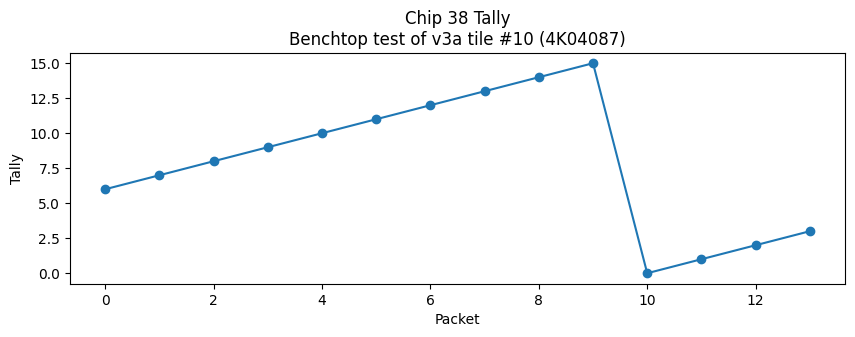

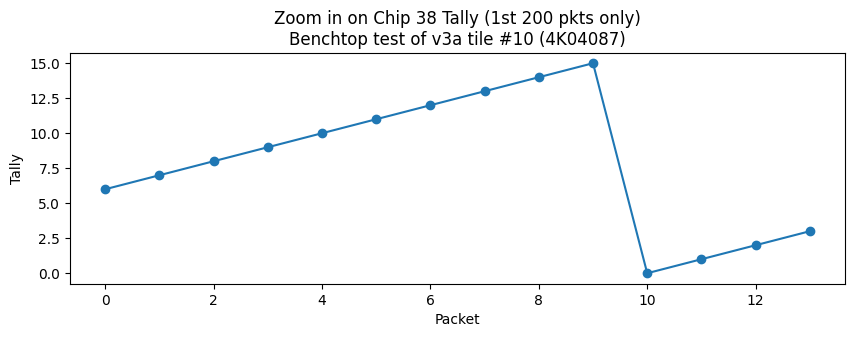

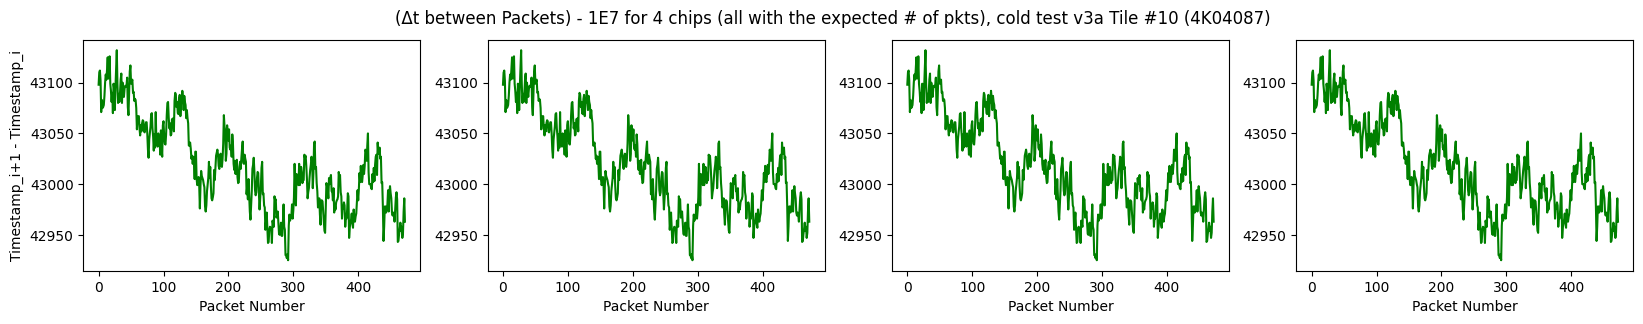

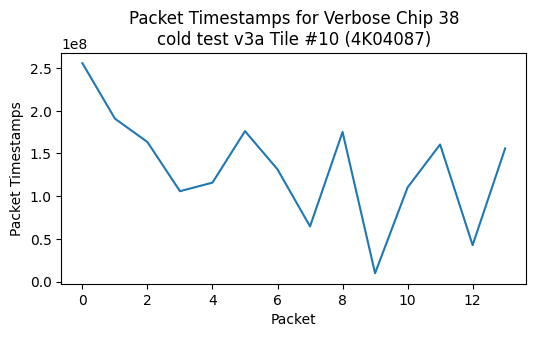

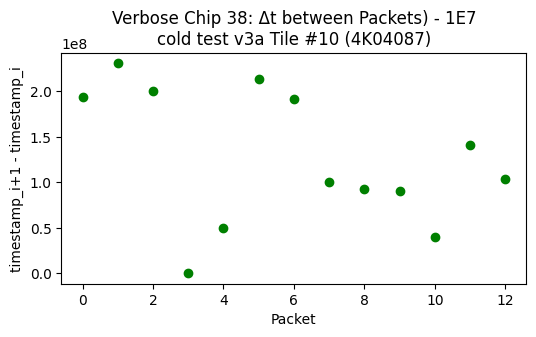

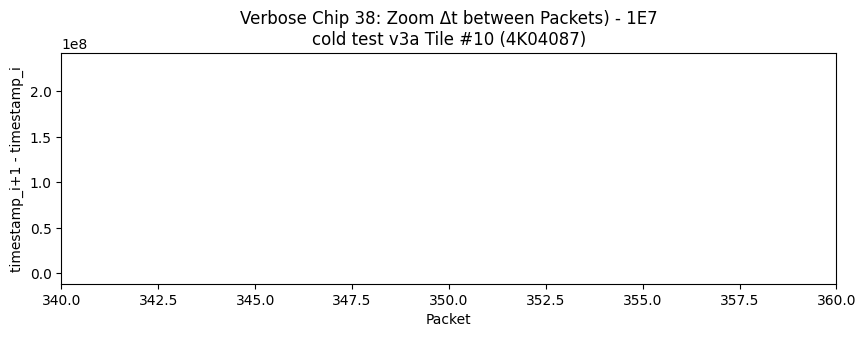

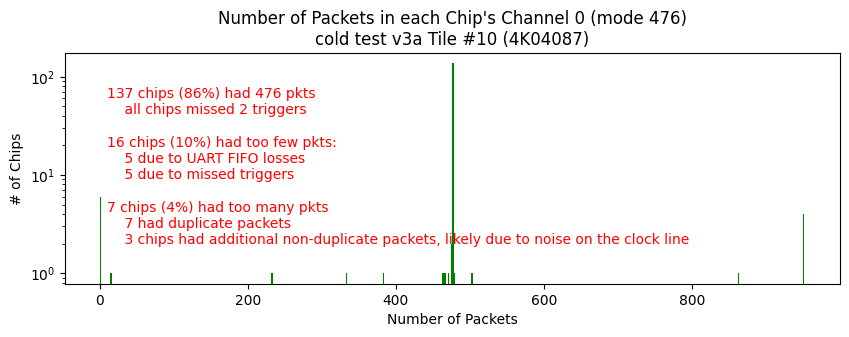

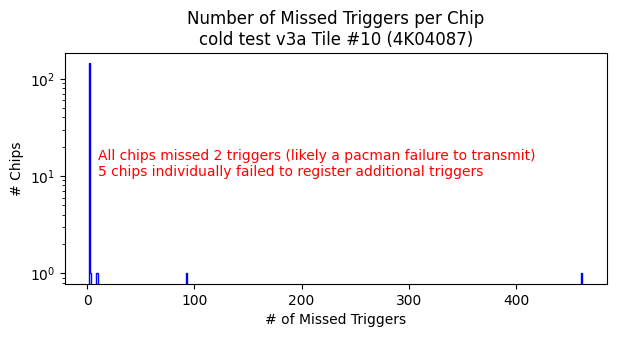

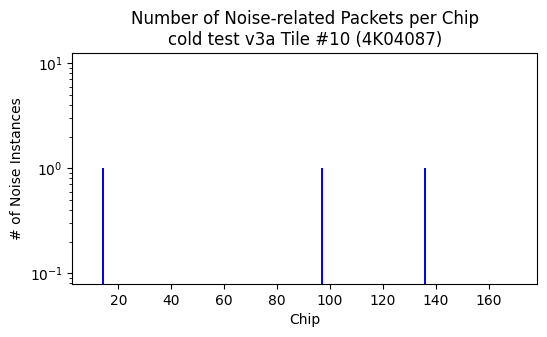

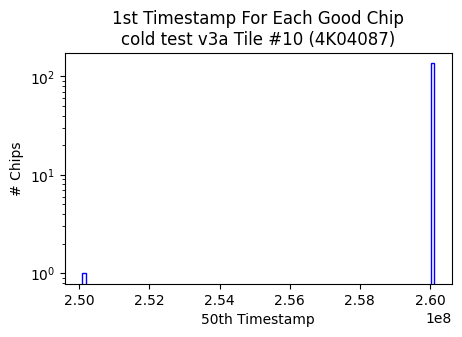

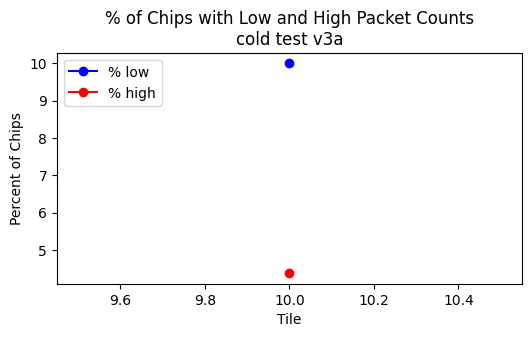

In [6]:
####################
# main
####################

print(f'\nData File {filename}:')

for tile in tiles:
    print(f"\n########################### Run Statistics Tile {tile} ###############################")
    
    get_timestamps(filename, tile, chip_serial_number_list[tile])

# graph % of chips that had low and high counts for each tile
fig, ax = plt.subplots(1,1, figsize=(6, 3))
ax.plot(tile_list, percent_low_list , label="% low", color = 'b', marker='o')
ax.plot(tile_list, percent_high_list, label="% high", color = 'r', marker='o')
ax.legend(loc="upper left")
ax.set_title(f"% of Chips with Low and High Packet Counts\n{temp} test v3a")
ax.set_xlabel("Tile")
ax.set_ylabel("Percent of Chips")
